<a href="https://colab.research.google.com/github/kestrel677/UNSUPERVISED-MACHINE-LEARNING/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("/content/penguins.csv")

df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [ ]:
df.shape

(344, 5)

In [ ]:
df.columns

Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [ ]:
df.isnull().sum()

,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,9


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())


df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,344.000000,344.000000,344.000000,344.000000
mean,43.921930,17.151170,214.014620,4201.754386
std,5.443643,1.969027,259.797302,799.613058
min,32.100000,13.100000,-132.000000,2700.000000
25%,39.275000,15.600000,190.000000,3550.000000
50%,44.250000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,214.000000,4750.000000
max,59.600000,21.500000,5000.000000,6300.000000


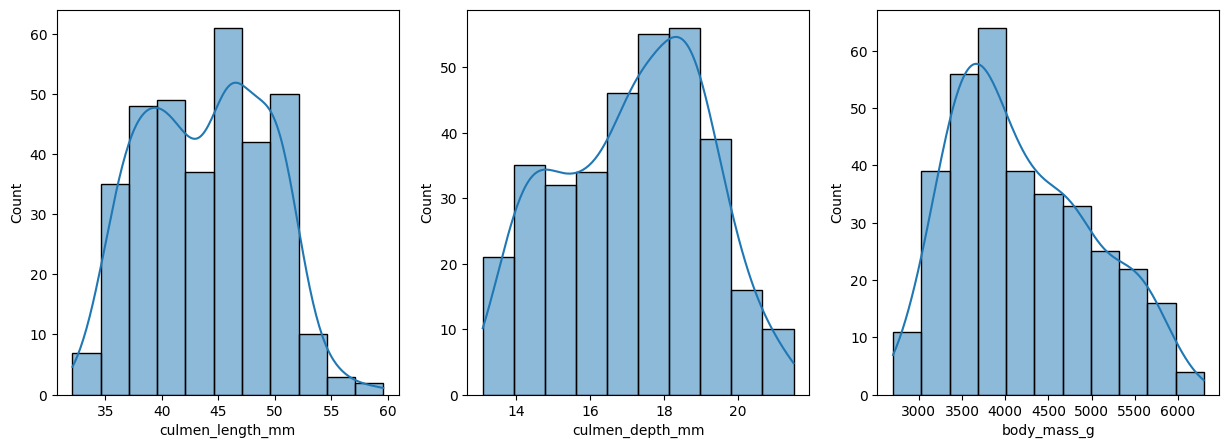

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df['culmen_length_mm'], kde=True)

plt.subplot(1,3,2)
sns.histplot(df['culmen_depth_mm'], kde=True)

plt.subplot(1,3,3)
sns.histplot(df['body_mass_g'], kde=True)

plt.show()

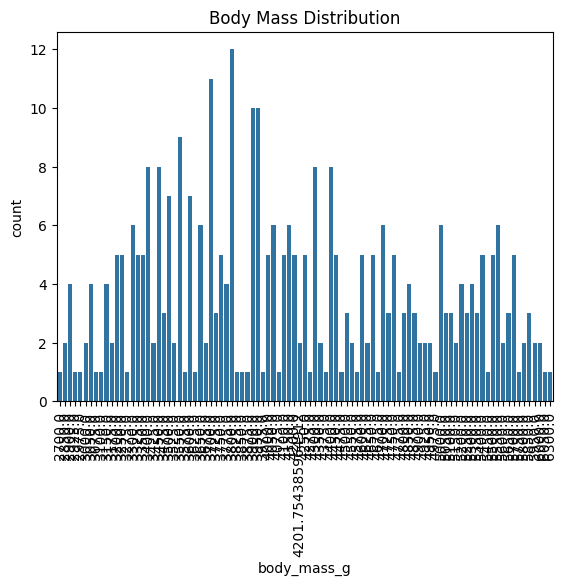

In [ ]:
sns.countplot(x='body_mass_g', data=df)

plt.title("Body Mass Distribution")

plt.xticks(rotation=90)

plt.show()

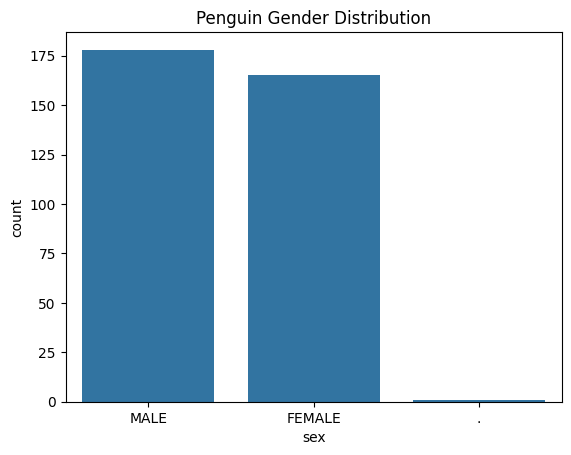

In [ ]:
sns.countplot(x='sex', data=df)

plt.title("Penguin Gender Distribution")

plt.show()

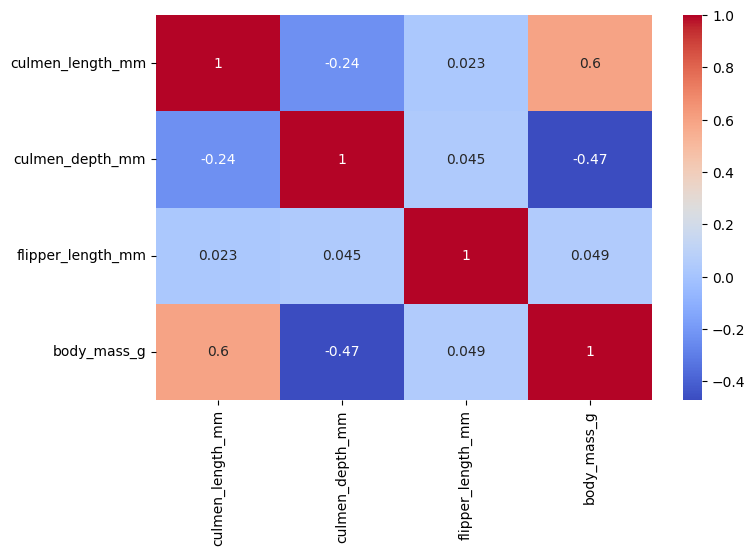

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.show()

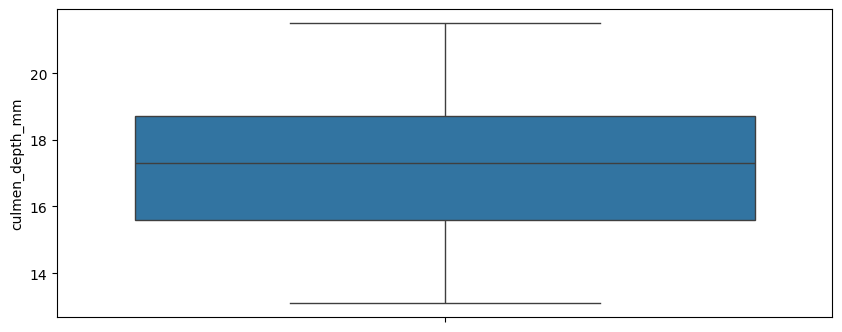

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(df['culmen_depth_mm'])

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['sex']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [ ]:
X_scaled[:5]

array([[-8.87081226e-01,  7.87742515e-01, -1.27263489e-01,
        -5.65789211e-01,  9.60230105e-01],
       [-8.13493989e-01,  1.26556330e-01, -1.07989681e-01,
        -5.03167881e-01, -1.01772891e+00],
       [-6.66319516e-01,  4.31719184e-01, -7.32968266e-02,
        -1.19200251e+00, -1.01772891e+00],
       [-1.30717191e-15,  1.80692708e-15,  0.00000000e+00,
         0.00000000e+00,  9.60230105e-01],
       [-1.32860464e+00,  1.09290537e+00, -8.10063498e-02,
        -9.41517191e-01, -1.01772891e+00]])

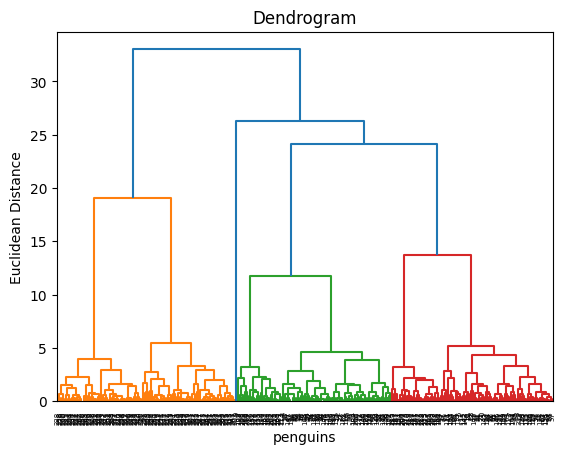

In [ ]:
from sklearn.preprocessing import StandardScaler

df_cleaned = df.dropna()
scaler_cleaned = StandardScaler()
X_scaled_cleaned = scaler_cleaned.fit_transform(df_cleaned)

linked = linkage(X_scaled_cleaned, method='ward')

dendrogram(linked)

plt.title("Dendrogram")

plt.xlabel("penguins")

plt.ylabel("Euclidean Distance")

plt.show()

In [ ]:
hc = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

In [ ]:
y_hc = hc.fit_predict(X_scaled_cleaned)

In [ ]:

df_cleaned_with_clusters = df_cleaned.copy()
df_cleaned_with_clusters['Cluster'] = y_hc

df['Cluster'] = df_cleaned_with_clusters['Cluster'].reindex(df.index)

In [ ]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,Cluster
0,39.10000,18.70000,181.00000,3750.000000,2,0
1,39.50000,17.40000,186.00000,3800.000000,1,1
2,40.30000,18.00000,195.00000,3250.000000,1,1
3,43.92193,17.15117,214.01462,4201.754386,2,0
4,36.70000,19.30000,193.00000,3450.000000,1,1


In [ ]:
cluster_profile = df.groupby('Cluster').mean()

cluster_profile

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
Cluster,,,,,
0,43.552177,19.062521,191.812761,3984.406328,2.000000
1,40.217757,17.611215,189.046729,3419.158879,1.000000
2,42.000000,20.200000,5000.000000,4250.000000,2.000000
3,49.212308,15.675385,220.861538,5426.923077,2.000000
4,45.545763,14.262712,212.779661,4683.050847,0.983051


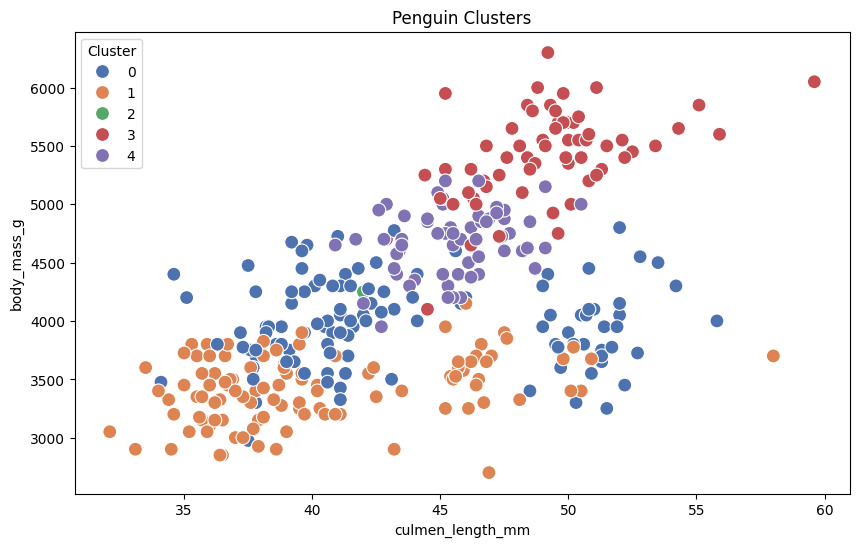

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['culmen_length_mm'],
    y=df['body_mass_g'],
    hue=df['Cluster'],
    palette='deep',
    s=100
)

plt.title("Penguin Clusters")

plt.show()

In [ ]:
score = silhouette_score(X_scaled, y_hc)

print("Silhouette Score:", score)

Silhouette Score: 0.5069434570506155


In [ ]:
pca = PCA()
x_pca = pca.fit_transform(X_scaled)

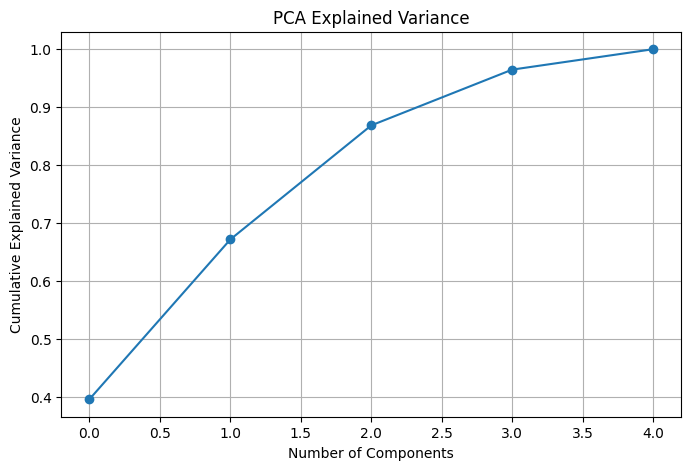

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

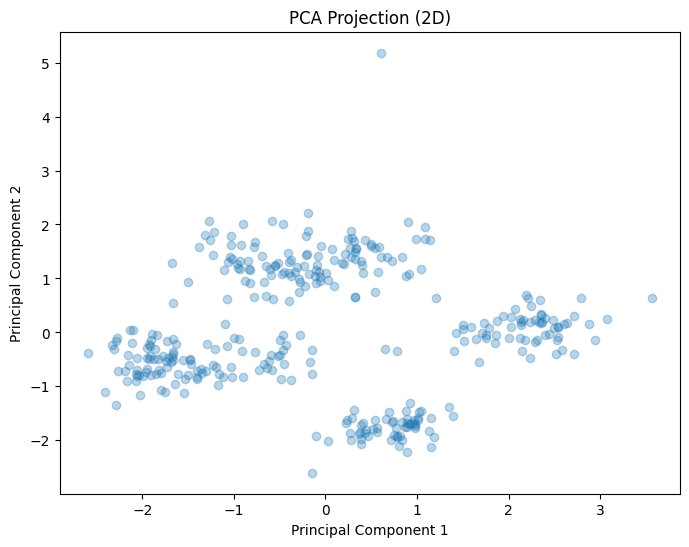

In [ ]:
pca_2 = PCA(n_components=2)

x_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(x_pca_2[:,0], x_pca_2[:,1], alpha=0.3)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Projection (2D)")

plt.show()

In [ ]:
# PCA Model
score_pca = silhouette_score(x_pca_2, y_hc)

print("Silhouette Score (PCA):", score_pca)

Silhouette Score (PCA): 0.6272159930209851
